<a href="https://colab.research.google.com/github/Goutham-26/DSA/blob/main/casestudy_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np

read data


In [44]:
data=pd.read_csv('/content/adult_dataset.csv')
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [45]:
data.shape

(48842, 15)

In [46]:
summary=pd.DataFrame({
    'Total Rows':len(data),
    'Null Rows':data.isnull().sum(),
    'Filled Rows':data.notnull().sum(),
})
summary

,Total Rows,Null Rows,Filled Rows
age,48842,2442,46400
workclass,48842,3362,45480
fnlwgt,48842,0,48842
education,48842,0,48842
education-num,48842,0,48842
marital-status,48842,0,48842
occupation,48842,3357,45485
relationship,48842,0,48842
race,48842,0,48842
sex,48842,0,48842


drop duplicate

In [47]:
data.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after dropping duplicates: {data.shape}")

Shape of DataFrame after dropping duplicates: (48826, 15)


<Axes: >

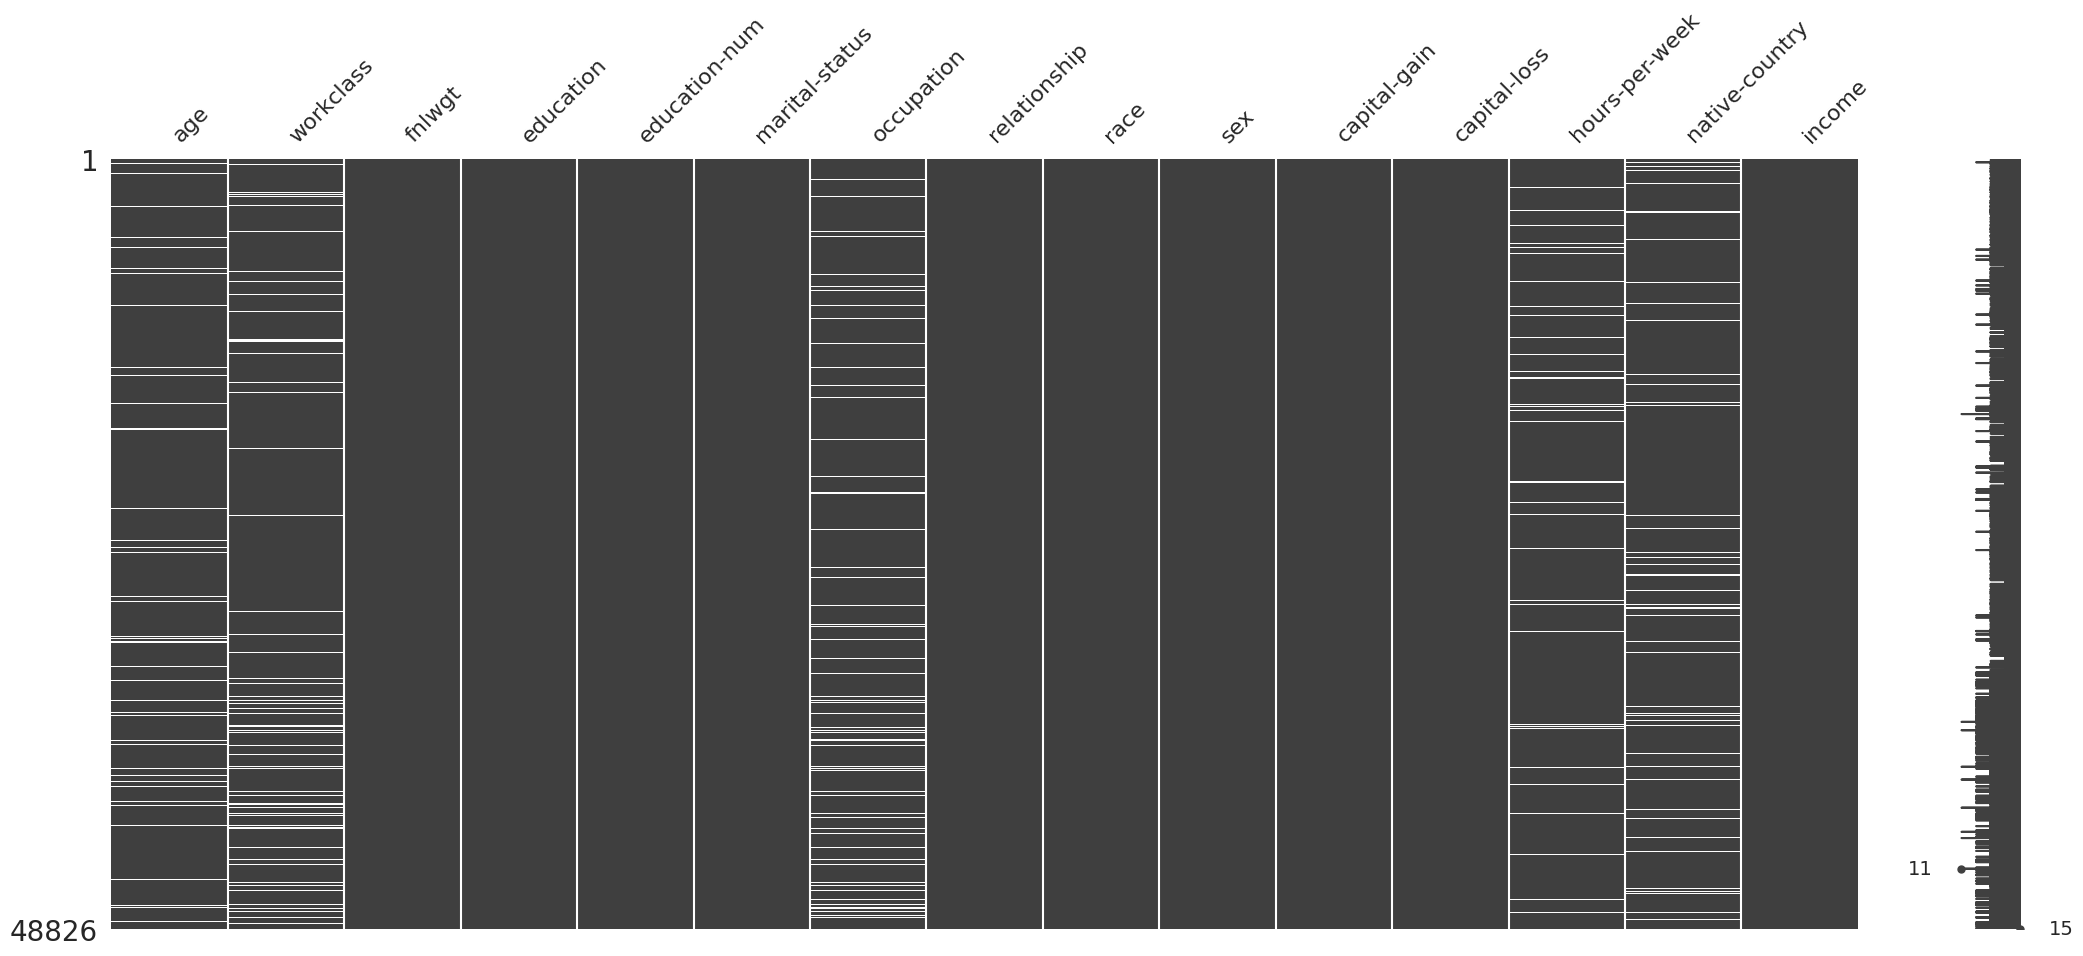

In [48]:
import missingno as msn
msn.matrix(data)

In [49]:
data.replace('?', np.nan, inplace=True)

In [50]:
for col in data.columns:
  if data[col].isnull().any():
    if data[col].dtype in ['float64','int64']:
      data[col]=data[col].fillna(data[col].median())
      print(f"Median is applied to the numbers in column: {col}")
    elif data[col].dtype=='object':
      data[col]=data[col].fillna(data[col].mode()[0])
      print(f"Mode is applied to the objects in column: {col}")

data.isnull().sum()

Median is applied to the numbers in column: age
Mode is applied to the objects in column: workclass
Mode is applied to the objects in column: occupation
Median is applied to the numbers in column: hours-per-week
Mode is applied to the objects in column: native-country


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


<Axes: >

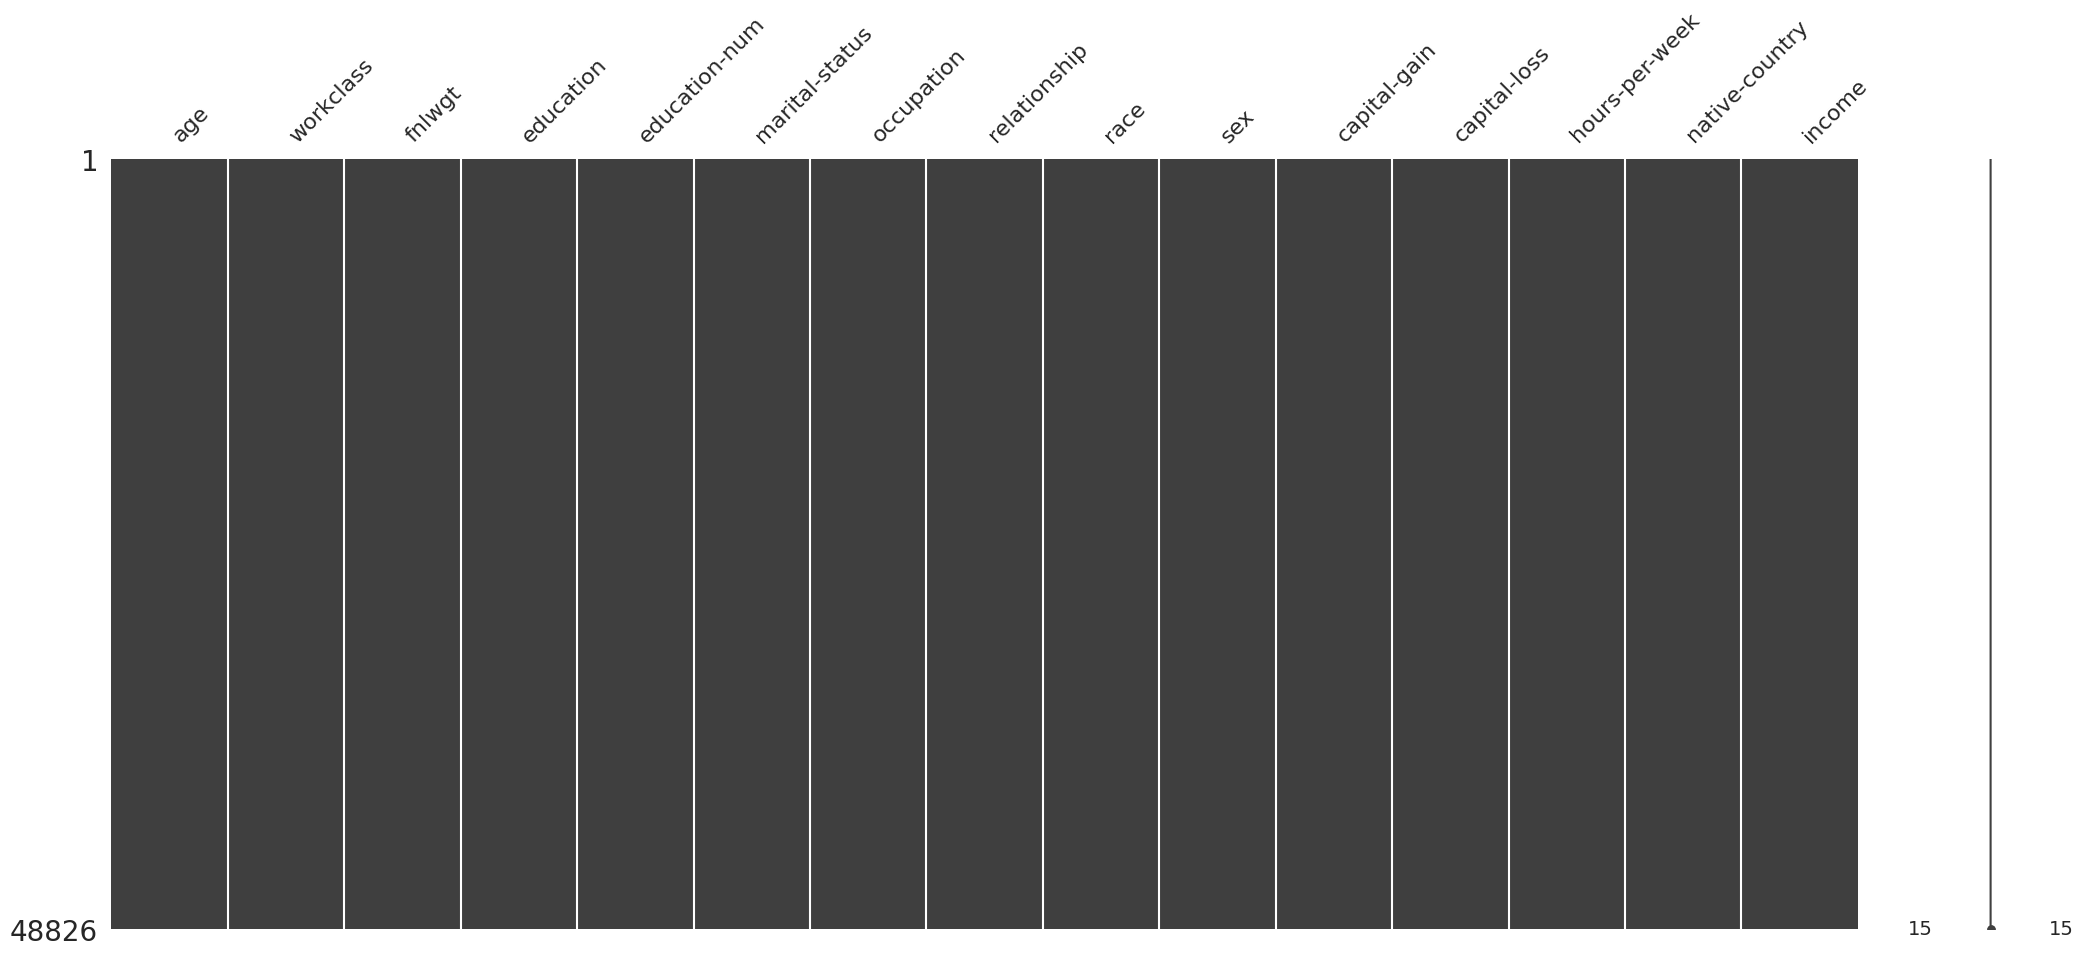

In [51]:

msn.matrix(data)

drawing graph

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_1636/919790465.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education', data=data, palette='Set2')
/tmp/ipykernel_1636/919790465.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='age', data=data, palette='Blues')


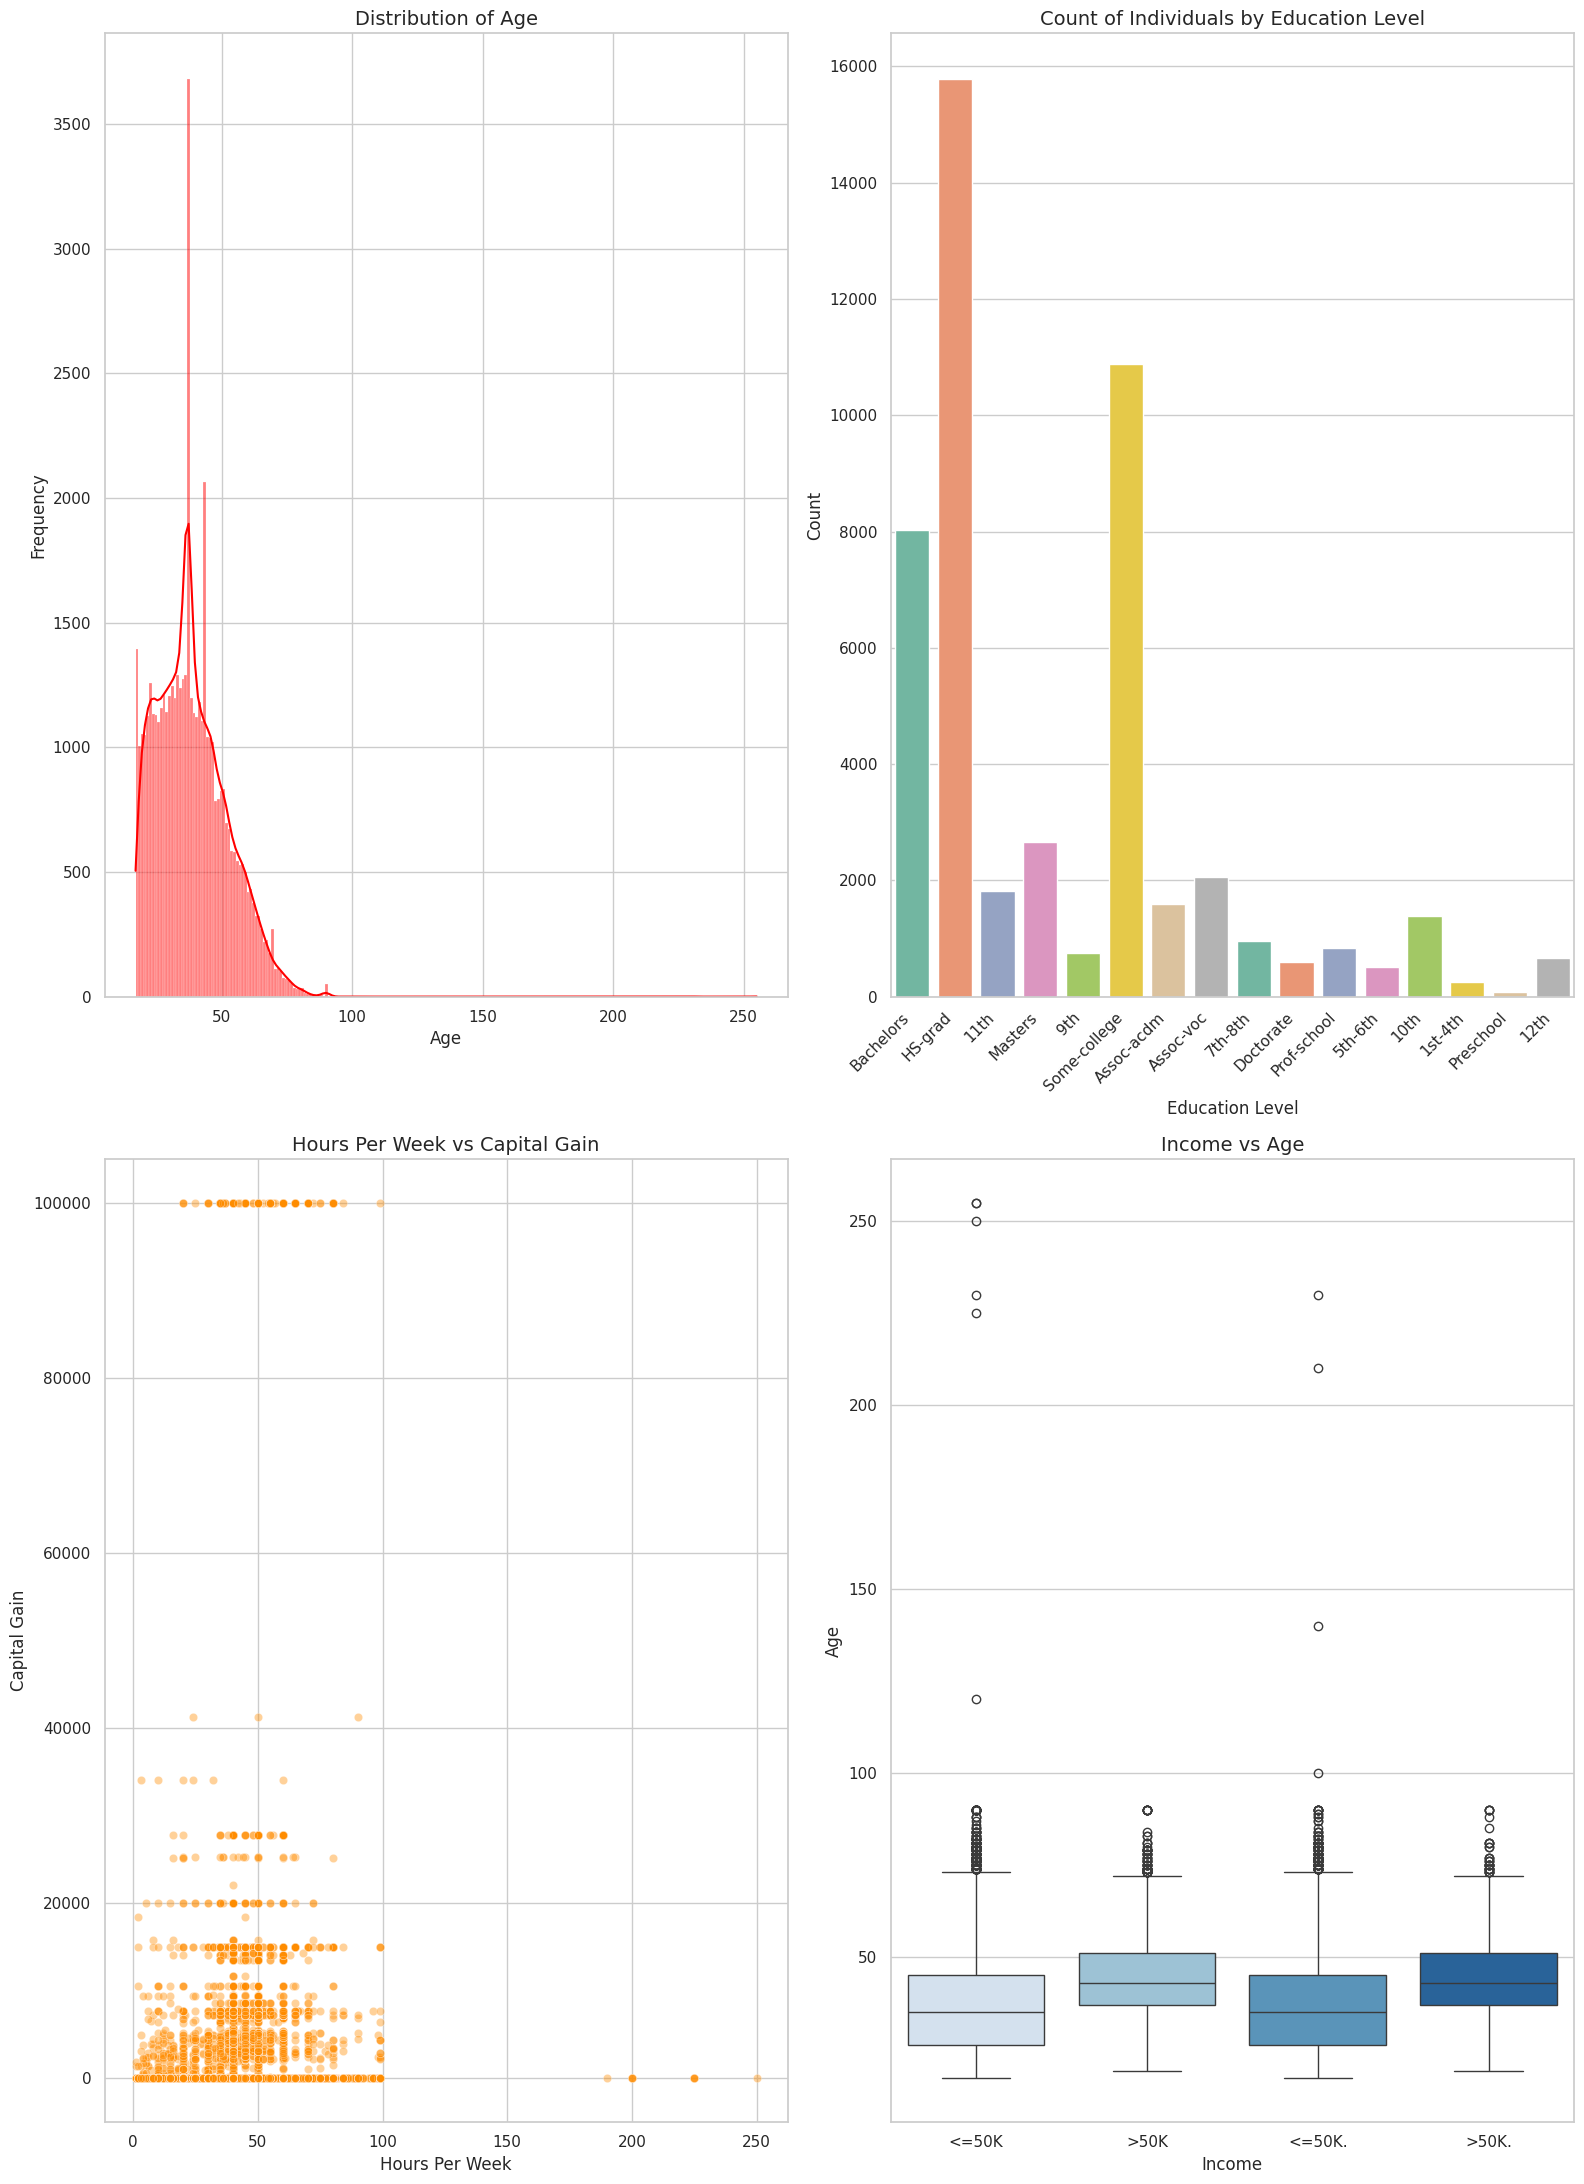

In [53]:
plt.figure(figsize=(16,22))

plt.subplot(2,2,1)
sns.histplot(data['age'], kde=True, color='red')
plt.title('Distribution of Age', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.countplot(x='education', data=data, palette='Set2')
plt.title('Count of Individuals by Education Level', fontsize=14)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate for better readability

plt.subplot(2, 2, 3)
sns.scatterplot(x='hours-per-week', y='capital-gain', data=data, alpha=0.4, color='darkorange')
plt.title('Hours Per Week vs Capital Gain', fontsize=14)
plt.xlabel('Hours Per Week')
plt.ylabel('Capital Gain')


plt.subplot(2, 2, 4)
sns.boxplot(x='income', y='age', data=data, palette='Blues')
plt.title('Income vs Age', fontsize=14)
plt.xlabel('Income')
plt.ylabel('Age')


plt.tight_layout()
plt.show()

IQR TO REMOVE OUTLIER

In [54]:
import numpy as np
import pandas as pd

outlier_cols = ['age', 'hours-per-week']

adult_dataset_cleaned = data.copy()

print(f"Shape before outlier removal: {adult_dataset_cleaned.shape}")

for col in outlier_cols:
    Q1 = adult_dataset_cleaned[col].quantile(0.25)
    Q3 = adult_dataset_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    adult_dataset_cleaned = adult_dataset_cleaned[
        (adult_dataset_cleaned[col] >= lower_bound) &
        (adult_dataset_cleaned[col] <= upper_bound)
    ]

print(f"Shape after outlier removal: {adult_dataset_cleaned.shape}")

Shape before outlier removal: (48826, 15)
Shape after outlier removal: (35869, 15)


labeling datas


In [55]:


from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

columns_to_encode = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'income'
]

for col in columns_to_encode:
    adult_dataset_cleaned[col] = label_encoder.fit_transform(adult_dataset_cleaned[col])
    print(f"Column '{col}' encoded successfully.")

display(adult_dataset_cleaned.head())
print("\nData types after encoding:")
display(adult_dataset_cleaned[columns_to_encode].dtypes)

Column 'workclass' encoded successfully.
Column 'education' encoded successfully.
Column 'marital-status' encoded successfully.
Column 'occupation' encoded successfully.
Column 'relationship' encoded successfully.
Column 'race' encoded successfully.
Column 'sex' encoded successfully.
Column 'native-country' encoded successfully.
Column 'income' encoded successfully.


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,6,77516,9,13,4,0,1,4,1,2174,0,40.0,38,0
2,38.0,3,215646,11,9,0,5,1,4,1,0,0,40.0,38,0
3,53.0,3,234721,1,7,2,5,0,2,1,0,0,40.0,38,0
4,28.0,3,338409,9,13,2,9,5,2,0,0,0,40.0,4,0
5,37.0,3,284582,12,14,2,3,5,4,0,0,0,40.0,38,0



Data types after encoding:


,0
workclass,int64
education,int64
marital-status,int64
occupation,int64
relationship,int64
race,int64
sex,int64
native-country,int64
income,int64


STANDARD SCALER


In [56]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

numerical_cols = adult_dataset_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Numerical columns found:", numerical_cols)

columns_to_exclude = []

features_to_scale = [col for col in numerical_cols if col not in columns_to_exclude]
print(f"\nFeatures that will be scaled:\n{features_to_scale}\n")

scaler = StandardScaler()

adult_dataset_scaled = adult_dataset_cleaned.copy()
adult_dataset_scaled[features_to_scale] = scaler.fit_transform(adult_dataset_cleaned[features_to_scale])

adult_dataset_scaled[features_to_scale].head()

Numerical columns found: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Features that will be scaled:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.033343,2.713487,-1.077511,-0.361111,1.142917,0.988051,-1.529061,-0.233769,0.404811,0.674766,0.174954,-0.219781,-0.373498,0.258368,-0.84999
2,-0.050170,-0.035691,0.229749,0.179869,-0.436833,-1.692664,-0.269741,-0.233769,0.404811,0.674766,-0.145386,-0.219781,-0.373498,0.258368,-0.84999
3,1.202524,-0.035691,0.410274,-2.525031,-1.226708,-0.352307,-0.269741,-0.859472,-1.916003,0.674766,-0.145386,-0.219781,-0.373498,0.258368,-0.84999
4,-0.885299,-0.035691,1.391575,-0.361111,1.142917,-0.352307,0.737714,2.269045,-1.916003,-1.481996,-0.145386,-0.219781,-0.373498,-5.485722,-0.84999
5,-0.133683,-0.035691,0.882158,0.450359,1.537855,-0.352307,-0.773469,2.269045,0.404811,-1.481996,-0.145386,-0.219781,-0.373498,0.258368,-0.84999


2,Exploratory analysis


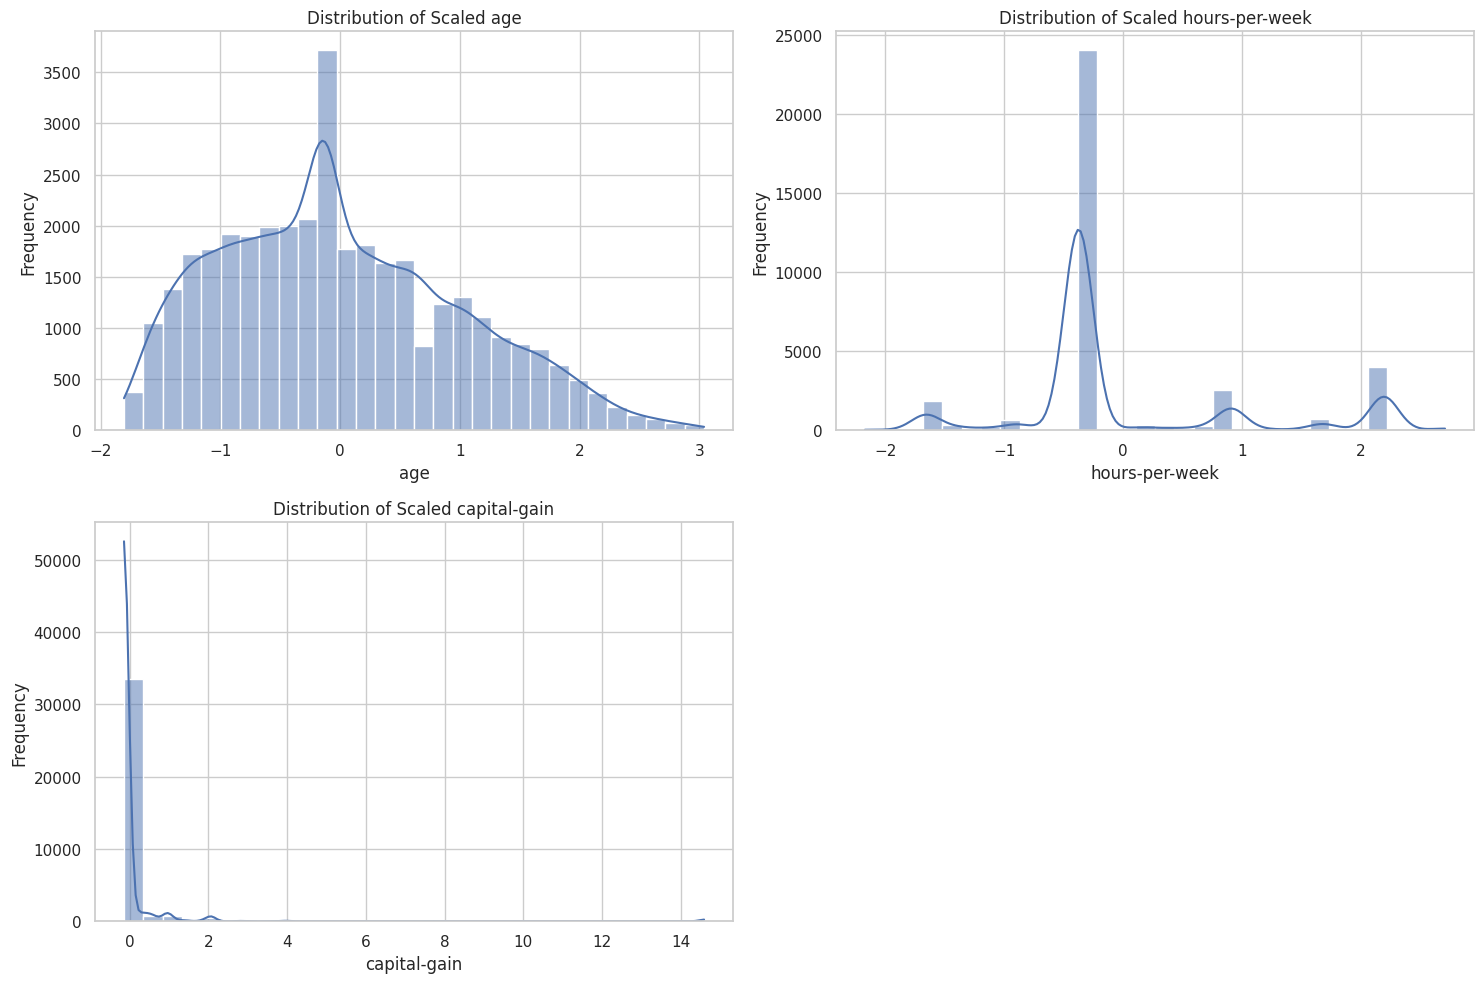

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

scaled_cols_to_plot = ['age', 'hours-per-week', 'capital-gain']

plt.figure(figsize=(15, 10))
for i, col in enumerate(scaled_cols_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.histplot(adult_dataset_scaled[col], kde=True, bins=30)
    plt.title(f'Distribution of Scaled {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

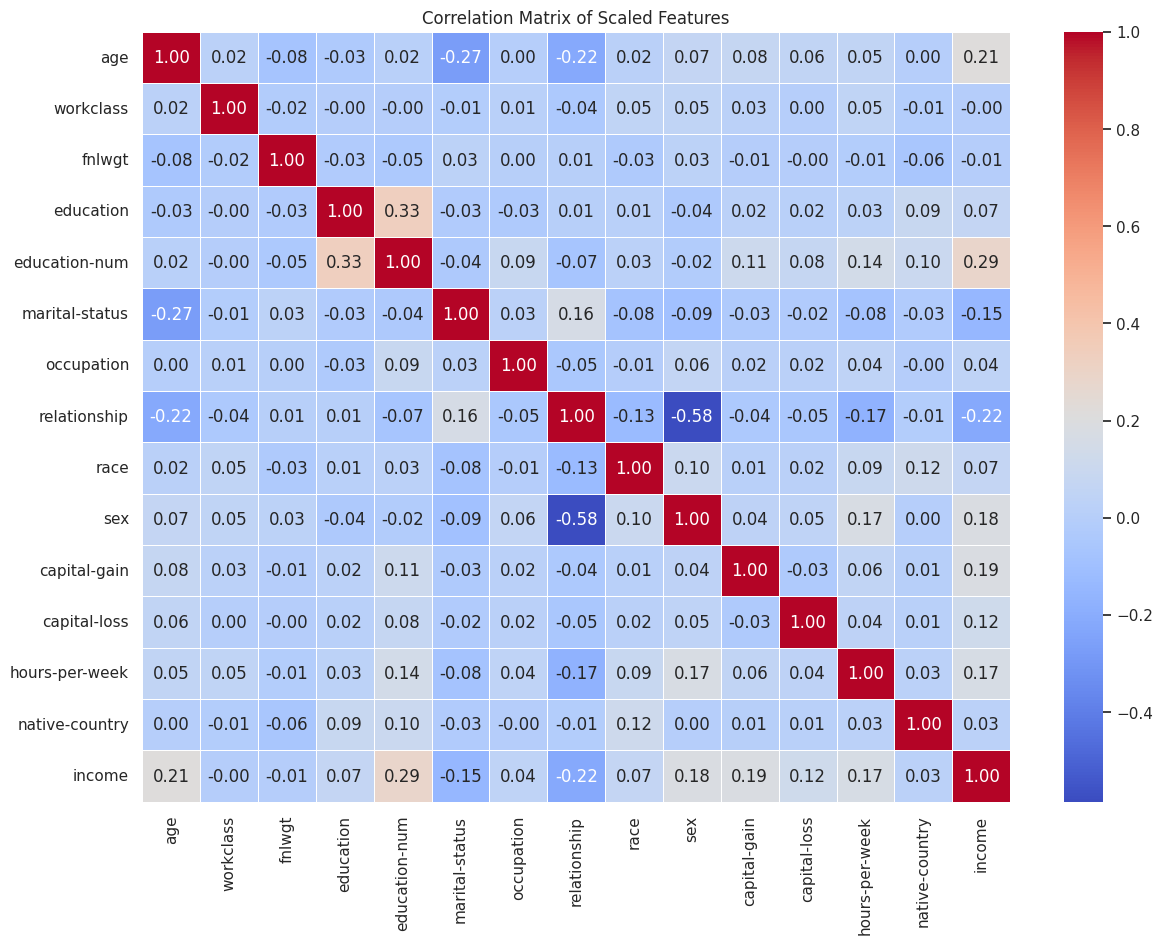

In [58]:
plt.figure(figsize=(14, 10))
sns.heatmap(adult_dataset_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Scaled Features')
plt.show()

pca

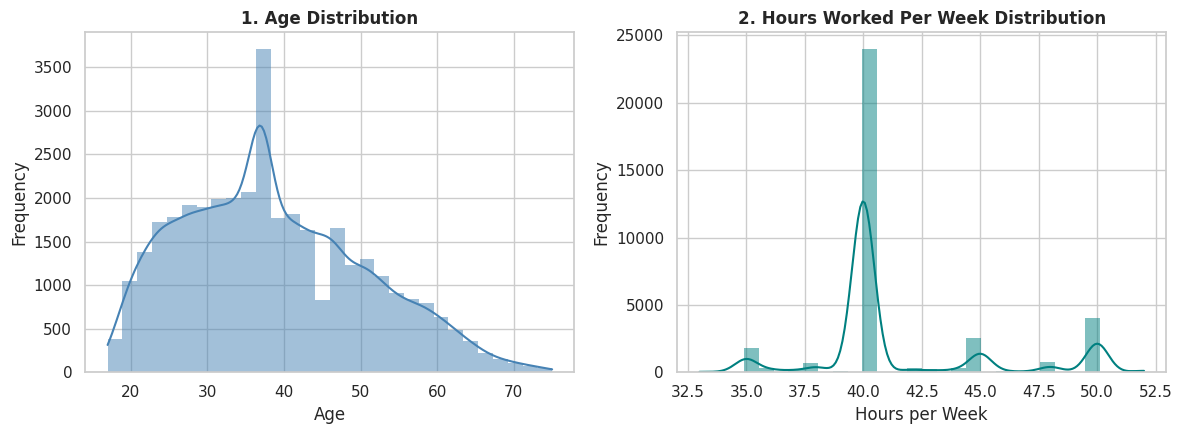

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

num_cols = ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss']

plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
sns.histplot(
    adult_dataset_cleaned['age'],
    kde=True,
    bins=30,
    color='steelblue',
    edgecolor='none',
)
plt.title('1. Age Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(
    adult_dataset_cleaned['hours-per-week'],
    kde=True,
    bins=30,
    color='teal',
    edgecolor='none',
)
plt.title('2. Hours Worked Per Week Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Hours per Week')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

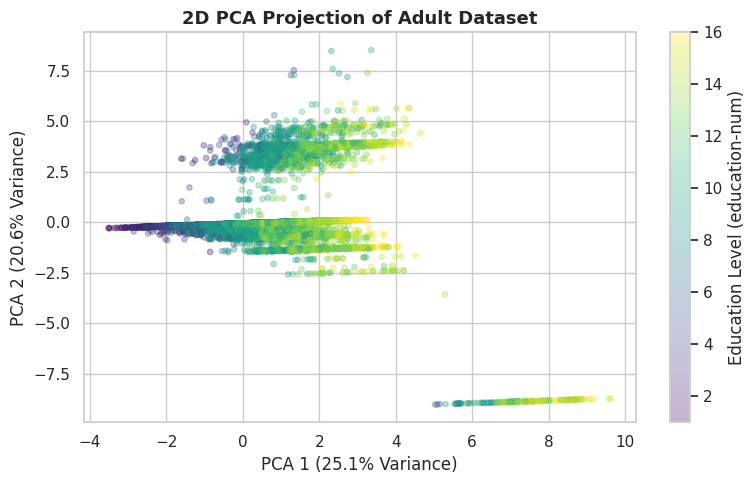

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(adult_dataset_cleaned[num_cols])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.3,
    c=adult_dataset_cleaned['education-num'],
    cmap='viridis',
    s=15,
)
plt.colorbar(label='Education Level (education-num)')
plt.title('2D PCA Projection of Adult Dataset', fontsize=13, fontweight='bold')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.tight_layout()
plt.show()

k-means

In [61]:
x=adult_dataset_scaled.values
from sklearn.cluster import KMeans

wcss_list=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(x)
  wcss_list.append(kmeans.inertia_)
wcss_list

[538034.9999999993,
 481884.2621758045,
 451439.0574815638,
 421031.9672600435,
 395482.97001382743,
 373239.32526232465,
 344467.59865973116,
 338688.5929421774,
 325959.43323861965,
 303795.11678155925]

Text(0, 0.5, 'wcss')

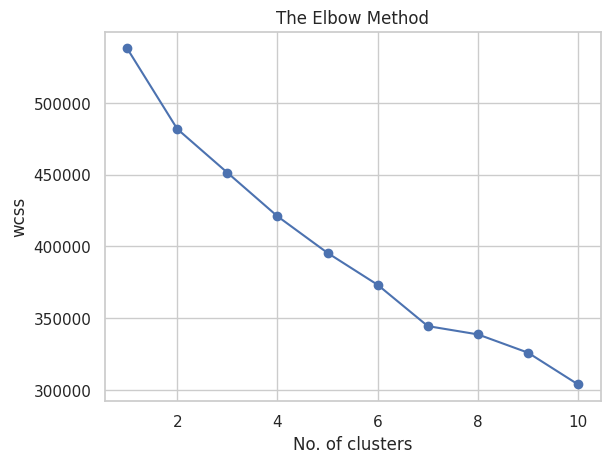

In [62]:
plt.plot(range(1,11),wcss_list,marker='o')
plt.title('The Elbow Method')
plt.xlabel('No. of clusters')
plt.ylabel('wcss')

In [63]:
kmeans_model=KMeans(n_clusters=5,init='k-means++',random_state=42,n_init=10)
y_predict=kmeans_model.fit_predict(x)
y_predict

array([0, 0, 4, ..., 0, 2, 0], dtype=int32)

In [64]:
adult_dataset_scaled['kmean_cluster']=y_predict
adult_dataset_scaled.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,kmean_cluster
0,0.033343,2.713487,-1.077511,-0.361111,1.142917,0.988051,-1.529061,-0.233769,0.404811,0.674766,0.174954,-0.219781,-0.373498,0.258368,-0.84999,0
2,-0.050170,-0.035691,0.229749,0.179869,-0.436833,-1.692664,-0.269741,-0.233769,0.404811,0.674766,-0.145386,-0.219781,-0.373498,0.258368,-0.84999,0
3,1.202524,-0.035691,0.410274,-2.525031,-1.226708,-0.352307,-0.269741,-0.859472,-1.916003,0.674766,-0.145386,-0.219781,-0.373498,0.258368,-0.84999,4
4,-0.885299,-0.035691,1.391575,-0.361111,1.142917,-0.352307,0.737714,2.269045,-1.916003,-1.481996,-0.145386,-0.219781,-0.373498,-5.485722,-0.84999,3
5,-0.133683,-0.035691,0.882158,0.450359,1.537855,-0.352307,-0.773469,2.269045,0.404811,-1.481996,-0.145386,-0.219781,-0.373498,0.258368,-0.84999,3


In [65]:
adult_dataset_scaled.shape

(35869, 16)

In [66]:
adult_dataset_scaled['kmean_cluster'].value_counts()

,count
kmean_cluster,
0,12738
3,9835
2,8931
4,4219
1,146


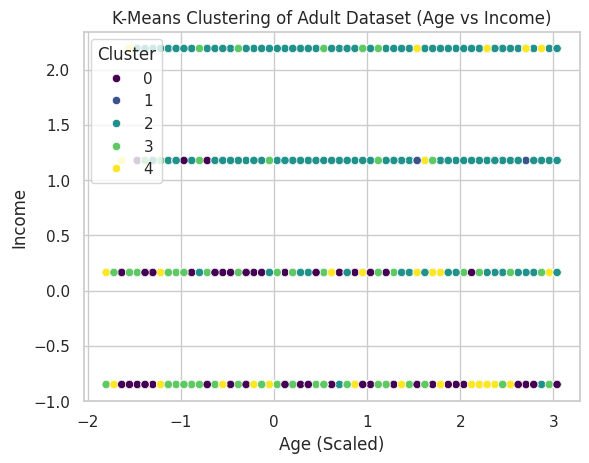

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='age', y='income', data=adult_dataset_scaled, hue='kmean_cluster', palette='viridis')
plt.xlabel('Age (Scaled)')
plt.ylabel('Income')
plt.title('K-Means Clustering of Adult Dataset (Age vs Income)')
plt.legend(title='Cluster')
plt.show()

In [68]:
from sklearn.metrics import silhouette_score
silhouette_average=silhouette_score(x,y_predict)
print('Silhouette Score',silhouette_average)

Silhouette Score 0.10891387811774486


Text(0, 0.5, 'Euclidean Distance')

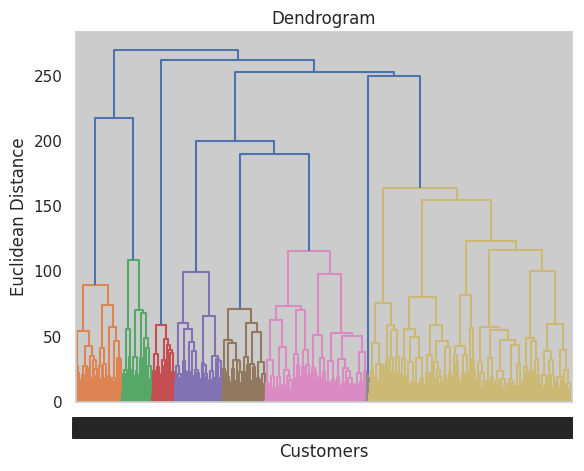

In [69]:
from scipy.cluster.hierarchy import dendrogram,linkage
mergings=linkage(x,method='ward')
dendrogram(mergings)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')

In [70]:
from scipy.cluster.hierarchy import fcluster
agglo_cluster=fcluster(mergings,t=50,criterion='distance') # Reduced t to 50
agglo_cluster

array([32, 43,  3, ..., 17, 39, 15], dtype=int32)

In [71]:
adult_dataset_scaled['agglo_cluster']=agglo_cluster
adult_dataset_scaled.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,kmean_cluster,agglo_cluster
0,0.033343,2.713487,-1.077511,-0.361111,1.142917,0.988051,-1.529061,-0.233769,0.404811,0.674766,0.174954,-0.219781,-0.373498,0.258368,-0.84999,0,32
2,-0.050170,-0.035691,0.229749,0.179869,-0.436833,-1.692664,-0.269741,-0.233769,0.404811,0.674766,-0.145386,-0.219781,-0.373498,0.258368,-0.84999,0,43
3,1.202524,-0.035691,0.410274,-2.525031,-1.226708,-0.352307,-0.269741,-0.859472,-1.916003,0.674766,-0.145386,-0.219781,-0.373498,0.258368,-0.84999,4,3
4,-0.885299,-0.035691,1.391575,-0.361111,1.142917,-0.352307,0.737714,2.269045,-1.916003,-1.481996,-0.145386,-0.219781,-0.373498,-5.485722,-0.84999,3,9
5,-0.133683,-0.035691,0.882158,0.450359,1.537855,-0.352307,-0.773469,2.269045,0.404811,-1.481996,-0.145386,-0.219781,-0.373498,0.258368,-0.84999,3,21


In [72]:
silhouette_average=silhouette_score(x,agglo_cluster)
print('Silhouette Score',silhouette_average)

Silhouette Score 0.07011714012349654


In [73]:
adult_dataset_scaled['agglo_cluster'].value_counts()

,count
agglo_cluster,
45,1974
18,1457
39,1433
37,1375
29,1374
46,1368
2,1308
23,1225
40,1180


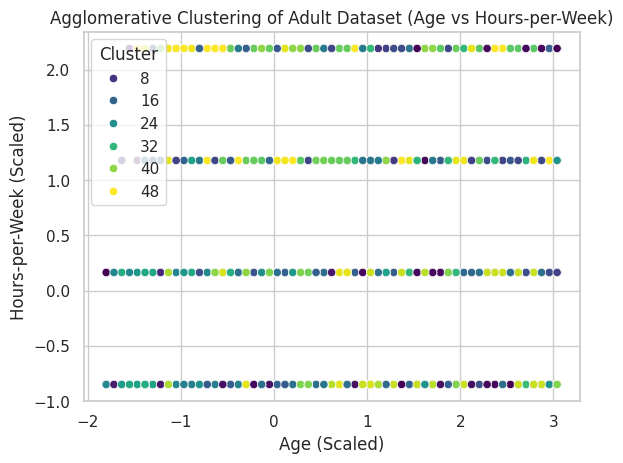

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='age', y='income', data=adult_dataset_scaled, hue='agglo_cluster', palette='viridis')
plt.xlabel('Age (Scaled)')
plt.ylabel('Hours-per-Week (Scaled)')
plt.title('Agglomerative Clustering of Adult Dataset (Age vs Hours-per-Week)')
plt.legend(title='Cluster')
plt.show()

In [75]:

adult_dataset_cleaned['kmean_cluster'] = adult_dataset_scaled['kmean_cluster'].values

profile_cols = [
    'age', 'education-num', 'hours-per-week',
    'capital-gain', 'capital-loss', 'income'
]


cluster_profile = adult_dataset_cleaned.groupby('kmean_cluster')[profile_cols].agg({
    'age': 'mean',
    'education-num': 'mean',
    'hours-per-week': 'mean',
    'capital-gain': 'mean',
    'capital-loss': 'mean',
    'income': ['count', 'mean']
}).round(2)

cluster_profile.columns = [
    'Avg Age', 'Avg Edu Level (Num)', 'Avg Weekly Hours',
    'Avg Capital Gain', 'Avg Capital Loss', 'Total Count', 'High Income Rate (>50K %)'
]

print("CLUSTER PROFILES & INCOME COMPARISON")
display(cluster_profile)


def assign_recommendation(row):
    if row['Avg Edu Level (Num)'] < 10.0:
        return "Upskilling programs (Focus on vocational & skill training)"
    elif row['High Income Rate (>50K %)'] > 0.35 or row['Avg Capital Gain'] > 1000:
        return "Tax reform (Optimizing brackets & capital gains taxes)"
    else:
        return "Financial aid or inclusion efforts (Economic safety nets & job assistance)"

display(cluster_profile[['Total Count', 'High Income Rate (>50K %)']])

CLUSTER PROFILES & INCOME COMPARISON


,Avg Age,Avg Edu Level (Num),Avg Weekly Hours,Avg Capital Gain,Avg Capital Loss,Total Count,High Income Rate (>50K %)
kmean_cluster,,,,,,,
0,35.03,10.17,41.25,166.16,36.57,12738,0.29
1,46.09,12.62,43.26,99999.00,0.00,146,2.35
2,44.87,11.61,43.26,1626.47,217.42,8931,2.10
3,36.93,10.60,40.39,338.32,56.87,9835,0.54
4,39.77,5.49,40.68,194.57,53.11,4219,0.45


,Total Count,High Income Rate (>50K %)
kmean_cluster,,
0,12738,0.29
1,146,2.35
2,8931,2.10
3,9835,0.54
4,4219,0.45
